
# Continuously Stirred Tank Reactor

In this example we will illustrate how Cantera can be used to simulate a
[continuously stirred tank reactor](https://en.wikipedia.org/wiki/Continuous_stirred-tank_reactor)_
(CSTR), also interchangeably referred to as a perfectly stirred reactor (PSR), a well
stirred reactor (WSR), a jet stirred reactor (JSR), or a
[Longwell reactor](https://nap.nationalacademies.org/read/13160/chapter/48)_ (and
there may well be more "aliases").

Requires: cantera >= 3.2, matplotlib >= 2.0, pandas

.. tags:: Python, combustion, reactor network, well-stirred reactor

## Simulation of a CSTR/PSR/WSR

A diagram of a CSTR is shown below:

<img src="file://_static/images/samples/stirred-reactor-solo.svg" width="50%" alt="A continuously stirred tank reactor with inflow and outflow" align="center">

As the figure illustrates, this is an open system (unlike a batch reactor, which is
isolated). *P*, *V* and *T* are the reactor's pressure, volume and temperature
respectively. The mass flow rate at which reactants come in is the same as that of the
products which exit, and on average this mass stays in the reactor for a characteristic
time $\tau$, called the *residence time*. This is a key quantity in sizing the
reactor and is defined as follows:

\begin{align}\tau = \frac{m}{\dot{m}}\end{align}

where $m$ is the mass of the gas.


## Import modules and set plotting defaults



In [1]:
import os
from pathlib import Path
import time
from copy import deepcopy

from tqdm import trange, tqdm

import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

from chem_operator.utils import get_mechanism_file
from chem_operator.datasets import CaseParameters, CaseSimulator, SimulationRecord, SimulationDatasetGenerator

from dataset_generator import CSTRCaseSimulator

prog_path = Path(os.path.abspath(""))
print(f"Running Cantera version: {ct.__version__}")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Running Cantera version: 3.2.0


## Define the gas

In this example, we will work with n-C₇H₁₆/O₂/He mixtures, for which experimental data
can be found in the paper by Zhang et al. [1]_ We will use the same mechanism reported
in the paper. It consists of 1268 species and 5336 reactions.



In [3]:
# gas = ct.Solution(get_mechanism_file("n-heptane-NUIG-2016.yaml"))
gas = ct.Solution("example_data/n-heptane-NUIG-2016.yaml")

CanteraError: 
*******************************************************************************
CanteraError thrown by Application::findInputFile:

Input file example_data/n-heptane-NUIG-2016.yaml not found in directories 
'.', 
'/home/rohan/SURF/experiment-v2/.venv/lib/python3.12/site-packages/cantera/data'

To fix this problem, either:
    a) move the missing files into the local directory;
    b) define environment variable CANTERA_DATA to
         point to the directory containing the file.
*******************************************************************************


In [3]:
tutorial_case = CaseParameters(
    initial_conditions={
        "gas/T": 925, # Kelvin
        "gas/P": 1.046138 * ct.one_atm, # in atm. This equals 1.06 bars
        "gas/X": {"NC7H16": 0.005, "O2": 0.0275, "HE": 0.9675}
    },
    geometry={
        "reactor_volume": 30.5 * (1e-2) ** 3, # m^3
    },
    controls={
        "residence_time": 2, # s
        "pressure_controller_K": 1e-6,
    },
    solver_parameters={
        "t_final": 50.0,
        "dt": None,
        "adaptive": True,
    },
    mechanism_parameters={}
)

cstr_simulator = CSTRCaseSimulator()
tutorial_sim = cstr_simulator.run_case(tutorial_case)

In [4]:
# this doesn't matter. solver will use substeps to reach goals of `advance`. changing dt can't ever degrade solver 

# dt_sims = []
# for dt in tqdm(np.geomspace(1e-2, 1.0, 5)):
#     case = deepcopy(tutorial_case)
#     case.solver_parameters["dt"] = dt
#     case.solver_parameters["adaptive"] = False
#     dt_sims.append(cstr_simulator.run_case(case))

# plt.figure()
# for sim in dt_sims:
#     dt = sim.metadata["solver_parameters"]["dt"]
#     cur_states = sim.to_SolutionArray()
#     plt.semilogx(cur_states.t, cur_states("CO").X, "-o")
#     plt.xlabel("Time (s)")
#     plt.ylabel("Mole Fraction : $X_{CO}$")

In [5]:
states = tutorial_sim.to_SolutionArray()

x_df = pd.DataFrame(
    states.X,
    columns=states.species_names,
)

# Mean mole fraction of each species, largest first
mean_x = x_df.mean(axis=0).sort_values(ascending=False)

mean_x.head(20)

HE         0.956549
O2         0.020288
H2O        0.006266
CO         0.004966
C2H4       0.004182
NC7H16     0.001603
H2         0.001503
CH4        0.001107
C3H6       0.000792
CH2O       0.000576
CO2        0.000391
C4H8-1     0.000246
C5H10-1    0.000196
H2O2       0.000159
C2H3CHO    0.000122
HOCHO      0.000116
C2H6       0.000111
CH3CHO     0.000088
CH3CHCO    0.000084
C4H6       0.000059
dtype: float64

In [6]:
states.X.sum(axis=0)

array([2.15992439e-19, 1.51981622e-20, 3.31922358e+02, ...,
       9.81350360e-11, 3.42419128e-09, 2.74219992e-12], shape=(1268,))

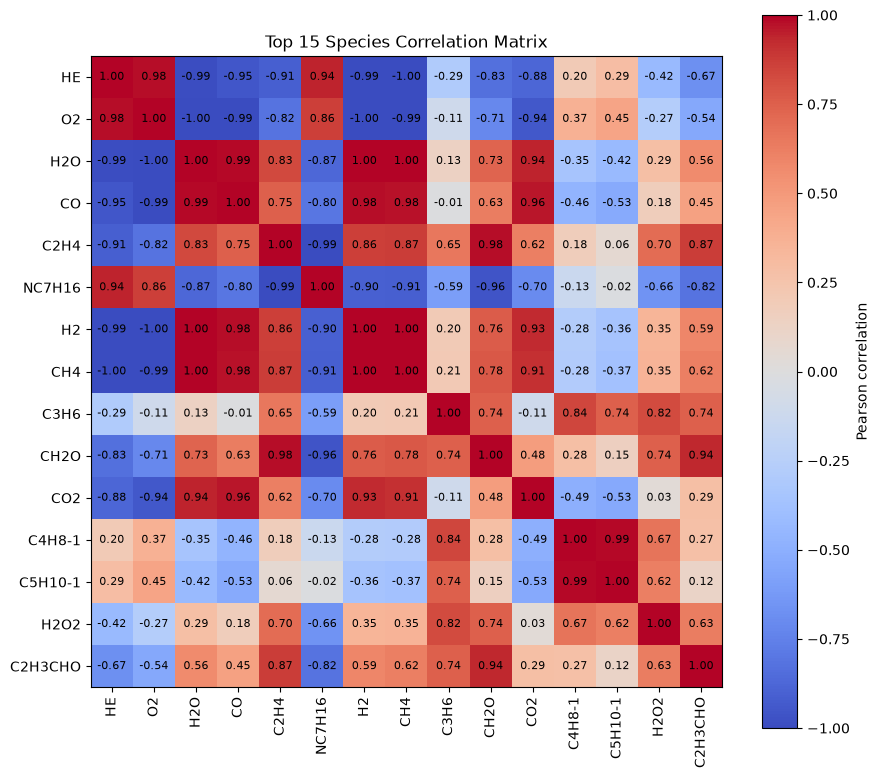

In [7]:
def plot_top_species_correlation(states, n=15, annotate=True):
    x_df = pd.DataFrame(states.X, columns=states.species_names)

    top_species = (
        x_df.mean()
        .sort_values(ascending=False)
        .head(n)
        .index
    )

    corr = x_df[top_species].corr()

    fig, ax = plt.subplots(figsize=(0.4 * n + 3, 0.4 * n + 2))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_xticks(range(n), labels=top_species, rotation=90)
    ax.set_yticks(range(n), labels=top_species)

    if annotate:
        for row in range(n):
            for col in range(n):
                ax.text(
                    col,
                    row,
                    f"{corr.iloc[row, col]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    fig.colorbar(image, ax=ax, label="Pearson correlation")
    ax.set_title(f"Top {n} Species Correlation Matrix")
    fig.tight_layout()
    plt.show()

    return corr

plot_top_species_correlation(states)
pass

In [8]:
X_species = states.X

X_non_species = np.column_stack([
    states.T,
    states.density,
])

X_raw = np.column_stack([
    X_non_species,
    X_species,
])

feature_names = [
    "temperature",
    "density",
    *states.species_names,
]

print("State matrix:", X_raw.shape)
print("Features:", len(feature_names))

State matrix: (347, 1270)
Features: 1270


In [9]:
def pod(y):
    """need to check if this works with nonzero mean"""
    n = len(y)
    y_mean = np.mean(y, axis=0)
    y = y - y_mean
    C = 1 / (n - 1) * y.T @ y
    w, v = np.linalg.eigh(C)
    w = np.flip(w)
    v = np.fliplr(v)
    return y_mean, v

In [10]:
from sklearn.preprocessing import StandardScaler
standardizer = StandardScaler().fit(X_raw)
X = standardizer.transform(X_raw)


# X = X_raw

sklearn_pca = PCA()
Z_sklearn = sklearn_pca.fit_transform(X)

sklearn_modes = sklearn_pca.components_.T
sklearn_eigenvalues = sklearn_pca.explained_variance_
sklearn_variance_ratio = sklearn_pca.explained_variance_ratio_

In [11]:
pod_mean, pod_modes = pod(X)

X_centered = X - pod_mean
Z_pod = X_centered @ pod_modes

pod_eigenvalues = np.var(Z_pod, axis=0, ddof=1)
pod_variance_ratio = pod_eigenvalues / pod_eigenvalues.sum()

In [12]:
n_compare = min(
    len(sklearn_eigenvalues),
    len(pod_eigenvalues),
)

abs_diff = np.abs(
    sklearn_eigenvalues[:n_compare]
    - pod_eigenvalues[:n_compare]
)

print("Maximum absolute difference:", abs_diff.max())
print("First 10 differences:", abs_diff[:10])

remaining = pod_eigenvalues[len(sklearn_eigenvalues):]

print("Largest remaining eigenvalue:", np.max(np.abs(remaining)))

Maximum absolute difference: 3.7180754807908225e-13
First 10 differences: [0.00000000e+00 3.41060513e-13 1.42108547e-13 1.42108547e-14
 8.88178420e-15 4.44089210e-16 1.55431223e-15 2.66453526e-15
 0.00000000e+00 3.21964677e-15]
Largest remaining eigenvalue: 3.3185247772366675e-14


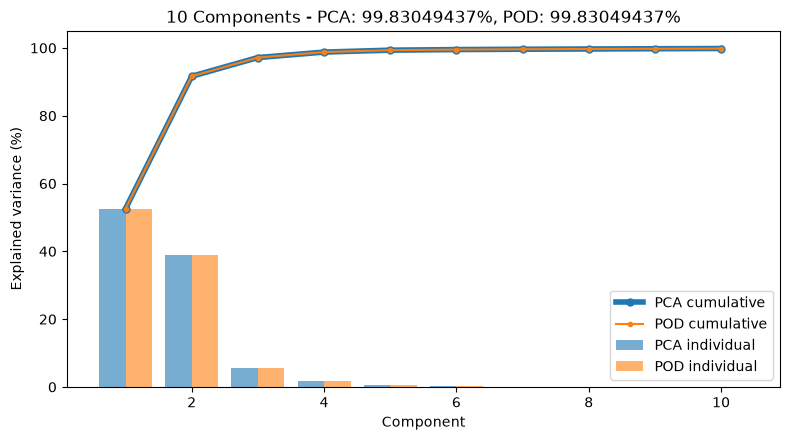

In [13]:
def plot_pca_pod_variance(
    pca: PCA,
    pod_eigenvalues: np.ndarray,
    n_components: int | None = None,
    dpi: int = 100,
    file_path: str | Path | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    """Compare PCA and POD explained variance on one axis."""

    pca_ratio = np.asarray(pca.explained_variance_ratio_)

    pod_eigenvalues = np.asarray(pod_eigenvalues)
    pod_ratio = pod_eigenvalues / pod_eigenvalues.sum()

    n = min(len(pca_ratio), len(pod_ratio))

    if n_components is not None:
        n = min(n, n_components)

    pca_ratio = pca_ratio[:n]
    pod_ratio = pod_ratio[:n]

    components = np.arange(1, n + 1)
    width = 0.4

    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=dpi)

    # Individual explained variance
    ax.bar(
        components - width / 2,
        pca_ratio * 100,
        width=width,
        color="C0",
        alpha=0.6,
        label="PCA individual",
    )
    ax.bar(
        components + width / 2,
        pod_ratio * 100,
        width=width,
        color="C1",
        alpha=0.6,
        label="POD individual",
    )

    # Cumulative explained variance
    ax.plot(
        components,
        np.cumsum(pca_ratio) * 100,
        color="C0",
        marker="o",
        markersize=5,
        lw=4,
        label="PCA cumulative",
    )
    ax.plot(
        components,
        np.cumsum(pod_ratio) * 100,
        color="C1",
        marker="o",
        markersize=3,
        label="POD cumulative",
    )

    ax.set_xlabel("Component")
    ax.set_ylabel("Explained variance (%)")
    ax.set_ylim(0, 105)
    ax.legend()

    pca_cumulative = pca_ratio[:n].sum()
    pod_cumulative = pod_ratio[:n].sum()

    ax.set_title(
        f"{n} Components - "
        f"PCA: {pca_cumulative:.8%}, "
        f"POD: {pod_cumulative:.8%}"
    )

    fig.tight_layout()

    if file_path is not None:
        fig.savefig(file_path, bbox_inches="tight", dpi=dpi)

    return fig, ax

fig, ax = plot_pca_pod_variance(
    pca=sklearn_pca,
    pod_eigenvalues=pod_eigenvalues,
    n_components=10,
)

In [14]:
len(gas.reaction_equations())

5336

In [15]:
print(states)
print(len(states.component_names))
print(len(states.species_names))
print(states.extra)
print(states)
non_species_components = [
    name
    for name in states.component_names
    if
    name not in states.species_names
]
print(non_species_components)

       T          D           AR           N2  ...   CVCCVCCJVO      CJVCCVO            t
0    925  0.0724065  0.00000e+00  0.00000e+00  ...  2.12677e-40  3.54146e-29  2.38148e-05
1    925  0.0724065  0.00000e+00  0.00000e+00  ...  3.81152e-35  5.98470e-28  1.21612e-04
2    925  0.0724065  0.00000e+00  0.00000e+00  ...  8.71005e-33  4.27998e-27  3.56264e-04
3    925  0.0724065  0.00000e+00  0.00000e+00  ...  3.53357e-31  2.46839e-26  8.53779e-04
4    925  0.0724065  0.00000e+00  0.00000e+00  ...  2.75296e-29  7.67175e-26  1.35129e-03
..   ...        ...          ...          ...  ...          ...          ...          ...
342  925  0.0711243  5.72349e-24  1.12396e-28  ...  1.82306e-10  1.02016e-13  3.77661e+01
343  925  0.0711243  4.96264e-23  1.02122e-28  ...  1.82306e-10  1.02016e-13  4.05066e+01
344  925  0.0711243  2.75162e-23  9.37580e-29  ...  1.82306e-10  1.02016e-13  4.32472e+01
345  925  0.0711243  3.12683e-24  5.16774e-29  ...  1.82306e-10  1.02016e-13  4.59878e+01
346  925  

### Plot the results

As a test, we plot the mole fraction of CO and see if the simulation has converged. If
not, go back and adjust max. number of steps and/or simulation time.



Text(0, 0.5, 'Frequency')

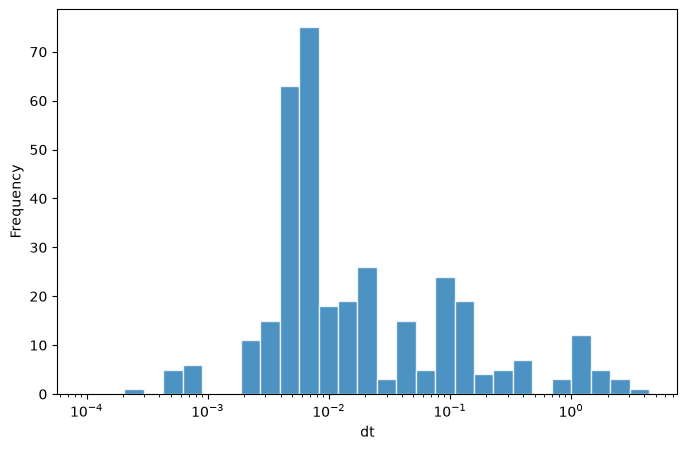

In [16]:
data = np.diff(states.t)

bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 30)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data, bins=bins, edgecolor='white', alpha=0.8)
ax.set_xscale('log')

# 4. Add clear formatting
ax.set_xlabel('dt')
ax.set_ylabel('Frequency')

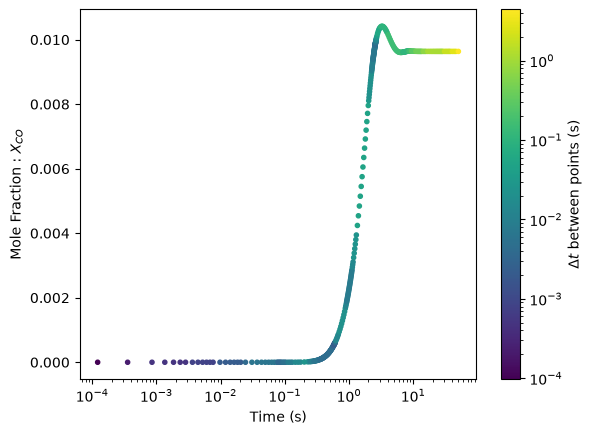

In [17]:
import matplotlib.pyplot as plt
import matplotlib

# HE         0.956549
# O2         0.020288
# H2O        0.006266
# CO         0.004966

t = np.asarray(states.t)
xco = np.asarray(states("CO").X).ravel()

dt = np.diff(t)

plt.figure()

sc = plt.scatter(
    t[1:],
    xco[1:],
    c=dt,
    s=9,
    norm=matplotlib.colors.LogNorm(),
)

plt.xscale("log")
plt.xlabel("Time (s)")
plt.ylabel("Mole Fraction : $X_{CO}$")

cbar = plt.colorbar(sc)
cbar.set_label(r"$\Delta t$ between points (s)")

plt.show()

In [18]:
# plt.figure()
# plt.semilogx(states.t, states.T, "-o")
# plt.xlabel("Time (s)")
# plt.ylabel("Mole Fraction T")
# plt.show()

# plt.figure()
# plt.semilogx(states.t, states.D, "-o")
# plt.xlabel("Time (s)")
# plt.ylabel("Mole Fraction : $X_{CO}$")
# plt.show()

In [19]:
# Define all the temperatures at which we will run simulations. These should overlap
# with the values reported in the paper as much as possible
T = [650, 700, 750, 775, 825, 850, 875, 925, 950, 1075, 1100]

# Create a SolutionArray to store values for the above points
temp_dependence = ct.SolutionArray(gas)

Now we simply run the reactor code we used above for each temperature

